In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
corona_dataset_csv = pd.read_csv("covid19_Confirmed_dataset.csv")

In [3]:
corona_dataset_csv.head(10)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27
5,NaN,Antigua and Barbuda,17.0608,-61.7964,0,0,0,0,0,0,...,23,24,24,24,24,24,24,24,24,24
6,NaN,Argentina,-38.4161,-63.6167,0,0,0,0,0,0,...,3031,3144,3435,3607,3780,3892,4003,4127,4285,4428
7,NaN,Armenia,40.0691,45.0382,0,0,0,0,0,0,...,1401,1473,1523,1596,1677,1746,1808,1867,1932,2066
8,Australian Capital Territory,Australia,-35.4735,149.0124,0,0,0,0,0,0,...,104,104,104,105,106,106,106,106,106,106
9,New South Wales,Australia,-33.8688,151.2093,0,0,0,0,3,4,...,2969,2971,2976,2982,2994,3002,3004,3016,3016,3025


In [4]:
corona_dataset_csv.shape

(266, 104)

In [5]:
columns = corona_dataset_csv.columns

In [6]:
list(columns)

['Province/State',
 'Country/Region',
 'Lat',
 'Long',
 '1/22/20',
 '1/23/20',
 '1/24/20',
 '1/25/20',
 '1/26/20',
 '1/27/20',
 '1/28/20',
 '1/29/20',
 '1/30/20',
 '1/31/20',
 '2/1/20',
 '2/2/20',
 '2/3/20',
 '2/4/20',
 '2/5/20',
 '2/6/20',
 '2/7/20',
 '2/8/20',
 '2/9/20',
 '2/10/20',
 '2/11/20',
 '2/12/20',
 '2/13/20',
 '2/14/20',
 '2/15/20',
 '2/16/20',
 '2/17/20',
 '2/18/20',
 '2/19/20',
 '2/20/20',
 '2/21/20',
 '2/22/20',
 '2/23/20',
 '2/24/20',
 '2/25/20',
 '2/26/20',
 '2/27/20',
 '2/28/20',
 '2/29/20',
 '3/1/20',
 '3/2/20',
 '3/3/20',
 '3/4/20',
 '3/5/20',
 '3/6/20',
 '3/7/20',
 '3/8/20',
 '3/9/20',
 '3/10/20',
 '3/11/20',
 '3/12/20',
 '3/13/20',
 '3/14/20',
 '3/15/20',
 '3/16/20',
 '3/17/20',
 '3/18/20',
 '3/19/20',
 '3/20/20',
 '3/21/20',
 '3/22/20',
 '3/23/20',
 '3/24/20',
 '3/25/20',
 '3/26/20',
 '3/27/20',
 '3/28/20',
 '3/29/20',
 '3/30/20',
 '3/31/20',
 '4/1/20',
 '4/2/20',
 '4/3/20',
 '4/4/20',
 '4/5/20',
 '4/6/20',
 '4/7/20',
 '4/8/20',
 '4/9/20',
 '4/10/20',
 '4/11/20',


### Delete Useless Columns

In [7]:
#Latitude and Longitude are not important features for us here
corona_dataset_csv.drop(["Lat","Long"],axis=1,inplace = True)

In [8]:
corona_dataset_csv.head()

,Province/State,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


### Aggregating the rows by the country

In [9]:
corona_dataset_aggregated = corona_dataset_csv.groupby("Country/Region").sum()

In [10]:
corona_dataset_aggregated.head()

,Province/State,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
Albania,0,0,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
Algeria,0,0,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
Andorra,0,0,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
Angola,0,0,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


In [11]:
type(corona_dataset_aggregated)

pandas.core.frame.DataFrame

### Visualizing data related to a country for example China

In [12]:
corona_dataset_aggregated.loc["China"].plot()

TypeError: no numeric data to plot

In [13]:
corona_dataset_aggregated.loc["China"]

Province/State    AnhuiBeijingChongqingFujianGansuGuangdongGuang...
1/22/20                                                         548
1/23/20                                                         643
1/24/20                                                         920
1/25/20                                                        1406
                                        ...                        
4/26/20                                                       83912
4/27/20                                                       83918
4/28/20                                                       83940
4/29/20                                                       83944
4/30/20                                                       83956
Name: China, Length: 101, dtype: object

<Axes: >

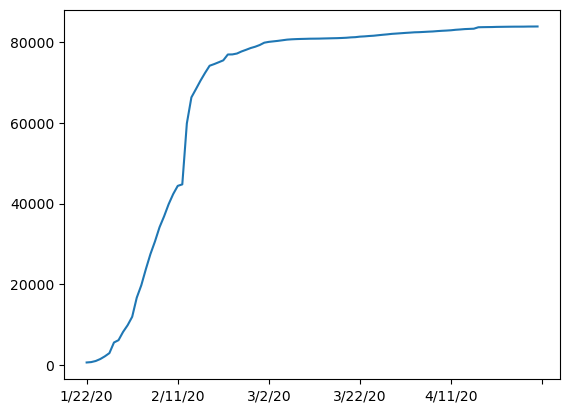

In [14]:
corona_dataset_aggregated.loc["China"][1:].plot()

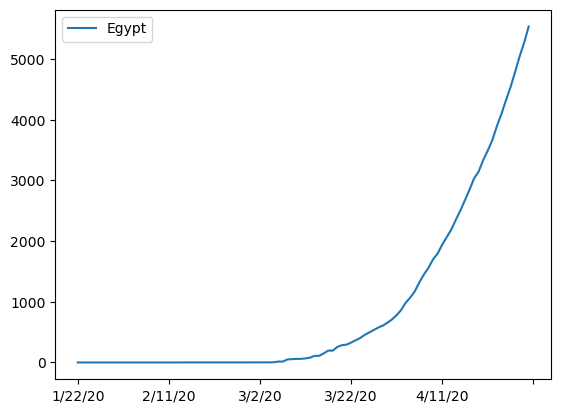

In [15]:
corona_dataset_aggregated.loc['Egypt'][1:].plot()
plt.legend()

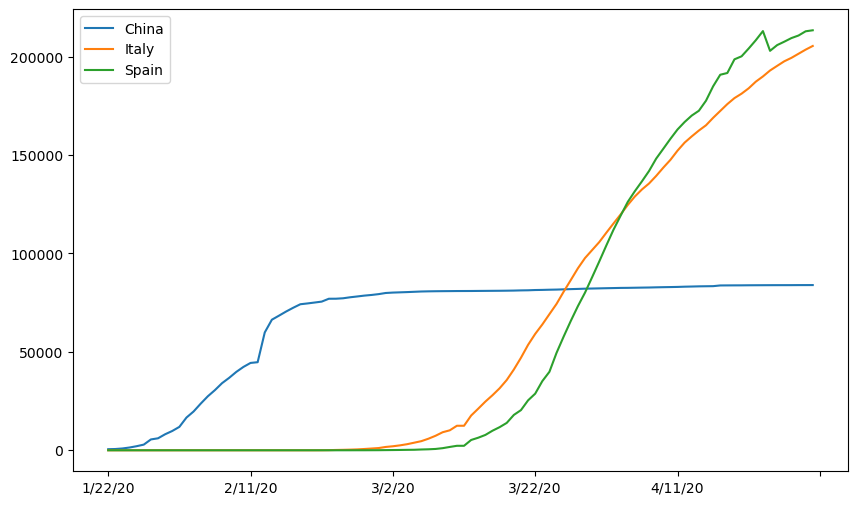

In [16]:
plt.figure(figsize=(10,6))
corona_dataset_aggregated.loc['China'][1:].plot()
corona_dataset_aggregated.loc['Italy'][1:].plot()
corona_dataset_aggregated.loc['Spain'][1:].plot()
plt.legend()

<Axes: >

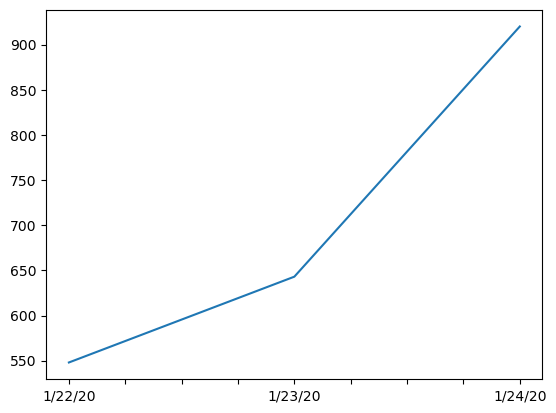

In [17]:
#Spread of the virus in China for the first 3 dates only
corona_dataset_aggregated.loc['China'][1:4].plot()

In [18]:
corona_dataset_aggregated.loc["China"].diff().plot()

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('int64'), dtype('<U232')) -> None

In [34]:
columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '4/21/20', '4/22/20', '4/23/20', '4/24/20', '4/25/20', '4/26/20',
       '4/27/20', '4/28/20', '4/29/20', '4/30/20'],
      dtype='object', length=104)

<Axes: >

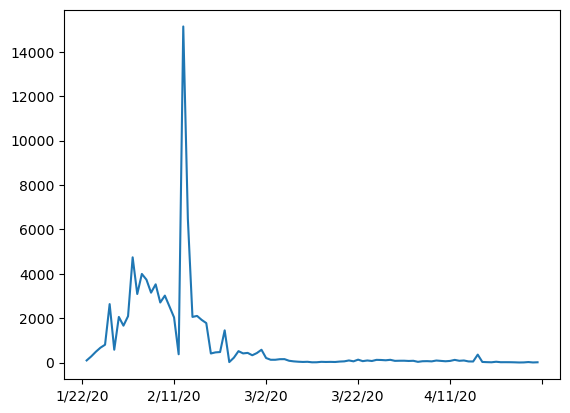

In [35]:
#caculating the first derivative of the curve
corona_dataset_aggregated.iloc[36,1:].diff().plot()

In [36]:
#This plot shows us the change in infection rate day by day and what we are looking for is the maximum number.

In [37]:
corona_dataset_aggregated = corona_dataset_aggregated.iloc[::,1:]

### find maxmimum infection rate for China

In [38]:
corona_dataset_aggregated.loc["China"].diff().max()
#In only 24 hrs, the difference was 15136

15136.0

In [39]:
corona_dataset_aggregated.loc["Italy"].diff().max()
#In only 24 hrs, the difference was 6557

6557.0

In [40]:
corona_dataset_aggregated.loc["Spain"].diff().max()
#In only 24 hrs, the difference was 9630

9630.0

### find maximum infection rate for all of the countries.

In [41]:
countries = list(corona_dataset_aggregated.index)
max_infection_rates = []
for c in countries :
    max_infection_rates.append(corona_dataset_aggregated.loc[c].diff().max())
max_infection_rates

[232.0,
 34.0,
 199.0,
 43.0,
 5.0,
 6.0,
 291.0,
 134.0,
 497.0,
 1321.0,
 105.0,
 7.0,
 301.0,
 641.0,
 12.0,
 1485.0,
 2454.0,
 4.0,
 19.0,
 1.0,
 104.0,
 92.0,
 7.0,
 7502.0,
 26.0,
 137.0,
 41.0,
 21.0,
 6.0,
 45.0,
 31.0,
 203.0,
 2778.0,
 31.0,
 21.0,
 1138.0,
 15136.0,
 353.0,
 1.0,
 57.0,
 81.0,
 37.0,
 113.0,
 96.0,
 63.0,
 58.0,
 381.0,
 391.0,
 99.0,
 156.0,
 5.0,
 371.0,
 11536.0,
 269.0,
 32.0,
 130.0,
 7.0,
 134.0,
 20.0,
 9.0,
 5.0,
 267.0,
 26849.0,
 38.0,
 5.0,
 42.0,
 6933.0,
 403.0,
 156.0,
 6.0,
 68.0,
 167.0,
 132.0,
 12.0,
 10.0,
 3.0,
 72.0,
 210.0,
 99.0,
 1893.0,
 436.0,
 3186.0,
 91.0,
 1515.0,
 1131.0,
 6557.0,
 52.0,
 1161.0,
 40.0,
 264.0,
 29.0,
 851.0,
 289.0,
 300.0,
 69.0,
 3.0,
 48.0,
 61.0,
 17.0,
 13.0,
 21.0,
 90.0,
 234.0,
 7.0,
 14.0,
 10.0,
 235.0,
 190.0,
 58.0,
 52.0,
 2.0,
 41.0,
 1425.0,
 222.0,
 12.0,
 13.0,
 30.0,
 281.0,
 19.0,
 3.0,
 14.0,
 1346.0,
 89.0,
 2.0,
 69.0,
 208.0,
 107.0,
 386.0,
 144.0,
 1292.0,
 357.0,
 5.0,
 27.0,
 3683.0,

In [42]:
corona_dataset_aggregated["max_infection_rates"] = max_infection_rates

In [43]:
corona_dataset_aggregated.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20,max_infection_rates
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1176,1279,1351,1463,1531,1703,1828,1939,2171,232.0
Albania,0,0,0,0,0,0,0,0,0,0,...,634,663,678,712,726,736,750,766,773,34.0
Algeria,0,0,0,0,0,0,0,0,0,0,...,2910,3007,3127,3256,3382,3517,3649,3848,4006,199.0
Andorra,0,0,0,0,0,0,0,0,0,0,...,723,723,731,738,738,743,743,743,745,43.0
Angola,0,0,0,0,0,0,0,0,0,0,...,25,25,25,25,26,27,27,27,27,5.0


In [44]:
#create a new dataframe with only needed column
corona_data = pd.DataFrame(corona_dataset_aggregated["max_infection_rates"])

In [45]:
corona_data.head()

,max_infection_rates
Country/Region,
Afghanistan,232.0
Albania,34.0
Algeria,199.0
Andorra,43.0
Angola,5.0


## Happiness Dataset

In [46]:
happiness_report_csv = pd.read_csv("worldwide_happiness_report.csv")

In [47]:
happiness_report_csv.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### let's drop the useless columns

In [48]:
useless_cols = ["Overall rank", "Score", "Generosity", "Perceptions of corruption"]
happiness_report_csv.drop(useless_cols, axis=1, inplace=True)
happiness_report_csv.head()

,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
0,Finland,1.340,1.587,0.986,0.596
1,Denmark,1.383,1.573,0.996,0.592
2,Norway,1.488,1.582,1.028,0.603
3,Iceland,1.380,1.624,1.026,0.591
4,Netherlands,1.396,1.522,0.999,0.557


### changing the indices of the dataframe

In [49]:
happiness_report_csv.set_index("Country or region", inplace=True)
happiness_report_csv.head()

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Country or region,,,,
Finland,1.340,1.587,0.986,0.596
Denmark,1.383,1.573,0.996,0.592
Norway,1.488,1.582,1.028,0.603
Iceland,1.380,1.624,1.026,0.591
Netherlands,1.396,1.522,0.999,0.557


### now let's join two dataset we have prepared

In [50]:
#Inner join
data = corona_data.join(happiness_report_csv,how = "inner" )
data.head()

,max_infection_rates,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Afghanistan,232.0,0.350,0.517,0.361,0.000
Albania,34.0,0.947,0.848,0.874,0.383
Algeria,199.0,1.002,1.160,0.785,0.086
Argentina,291.0,1.092,1.432,0.881,0.471
Armenia,134.0,0.850,1.055,0.815,0.283


### correlation matrix

In [51]:
data.corr()

,max_infection_rates,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
max_infection_rates,1.000000,0.250118,0.191958,0.289263,0.078196
GDP per capita,0.250118,1.000000,0.759468,0.863062,0.394603
Social support,0.191958,0.759468,1.000000,0.765286,0.456246
Healthy life expectancy,0.289263,0.863062,0.765286,1.000000,0.427892
Freedom to make life choices,0.078196,0.394603,0.456246,0.427892,1.000000


<Axes: >

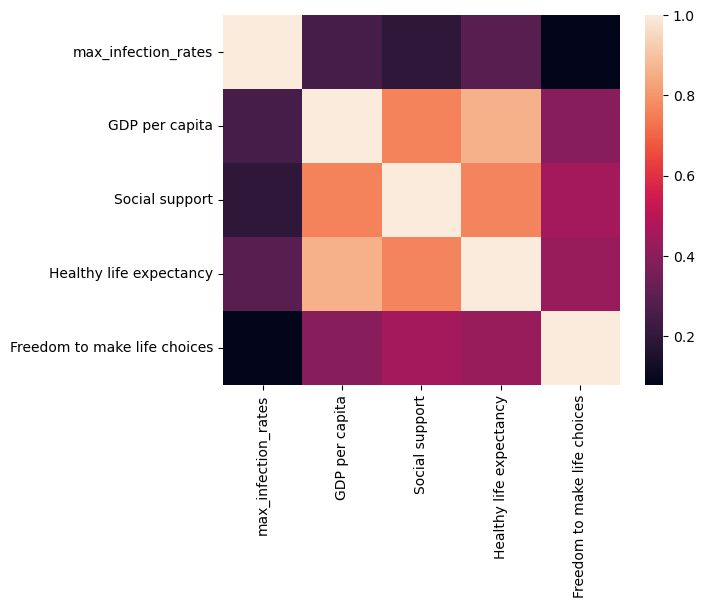

In [52]:
sns.heatmap(data=data.corr())

### Plotting GDP vs maximum Infection rate

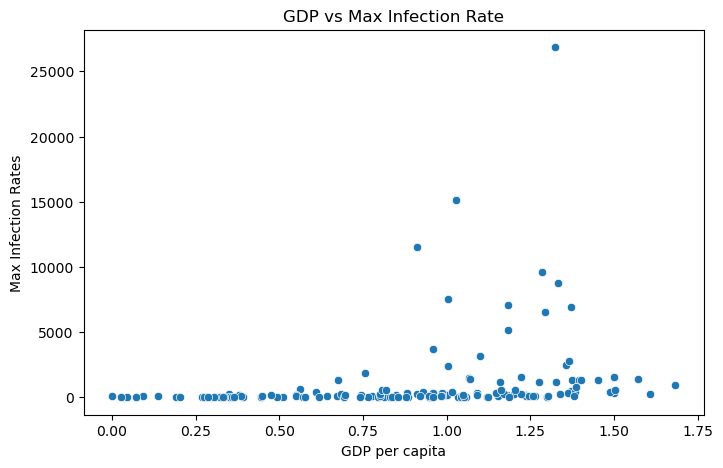

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

x = data["GDP per capita"]
y = data["max_infection_rates"]

plt.figure(figsize=(8,5))
sns.scatterplot(x=x, y=y)   # 👈 keyword arguments use karo
plt.xlabel("GDP per capita")
plt.ylabel("Max Infection Rates")
plt.title("GDP vs Max Infection Rate")
plt.show()


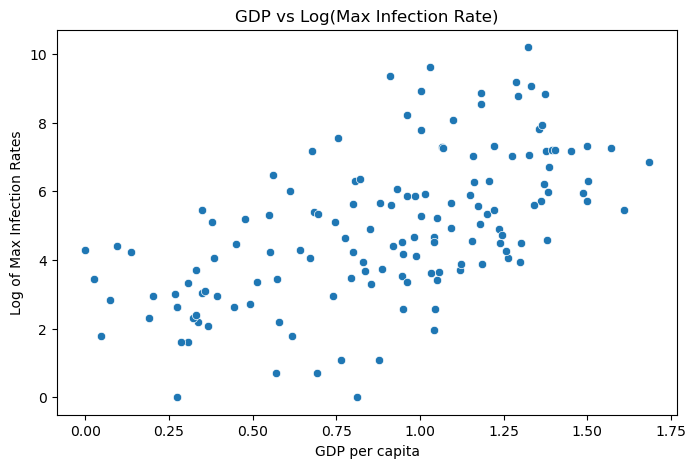

In [63]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define variables
x = data["GDP per capita"]
y = data["max_infection_rates"]

# Apply log transformation
y_log = np.log(y)

# Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=x, y=y_log)
plt.xlabel("GDP per capita")
plt.ylabel("Log of Max Infection Rates")
plt.title("GDP vs Log(Max Infection Rate)")
plt.show()

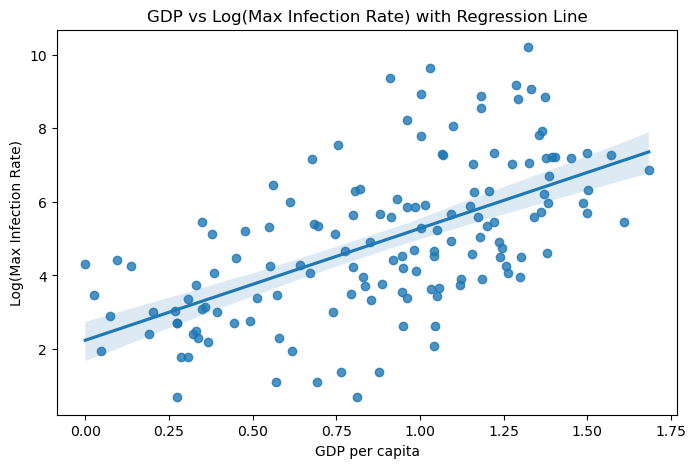

In [65]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
x = data["GDP per capita"]
y = data["max_infection_rates"]

# Safe log transform
y_log = np.log1p(y)

# Plot
plt.figure(figsize=(8,5))
sns.regplot(x=x, y=y_log)

plt.xlabel("GDP per capita")
plt.ylabel("Log(Max Infection Rate)")
plt.title("GDP vs Log(Max Infection Rate) with Regression Line")
plt.show()

### Plotting Social support vs maximum Infection rate

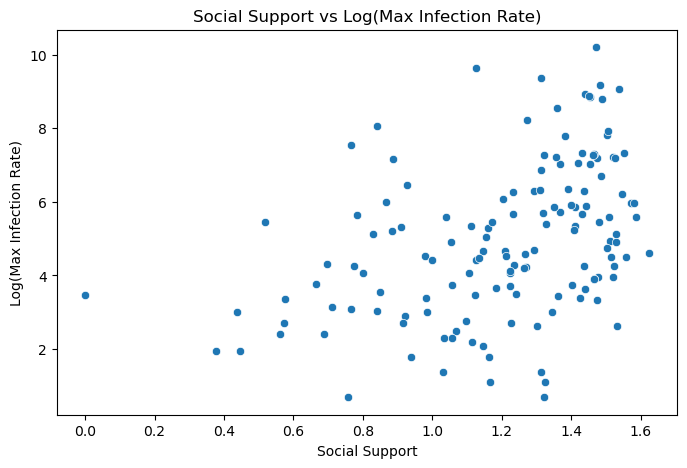

In [67]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = data["Social support"]
y = data["max_infection_rates"]

# Safe log transform
y_log = np.log1p(y)

plt.figure(figsize=(8,5))
sns.scatterplot(x=x, y=y_log)

plt.xlabel("Social Support")
plt.ylabel("Log(Max Infection Rate)")
plt.title("Social Support vs Log(Max Infection Rate)")
plt.show()

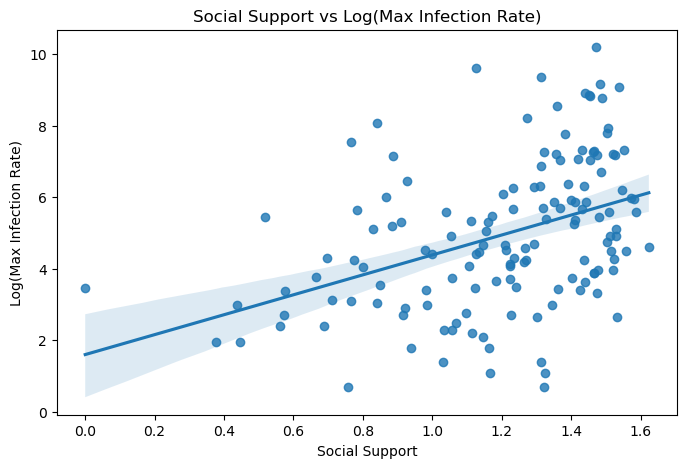

In [68]:
x = data["Social support"]
y = data["max_infection_rates"]

# Safe log transform
y_log = np.log1p(y)

plt.figure(figsize=(8,5))
sns.regplot(x=x, y=y_log)

plt.xlabel("Social Support")
plt.ylabel("Log(Max Infection Rate)")
plt.title("Social Support vs Log(Max Infection Rate)")
plt.show()

### Plotting Healthy life expectancy vs maximum Infection rate

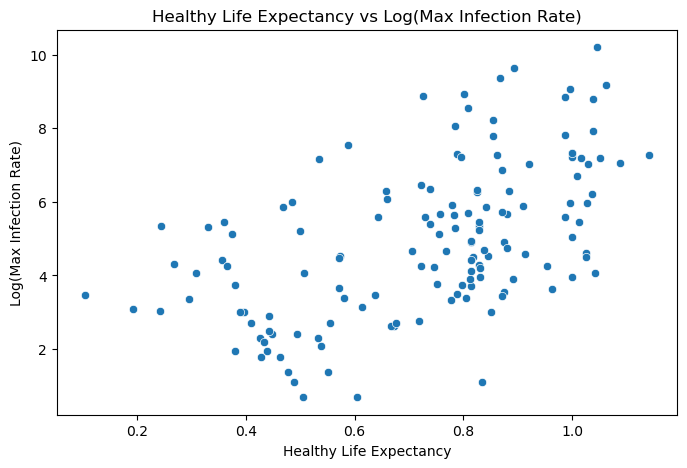

In [69]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = data["Healthy life expectancy"]
y = data["max_infection_rates"]

# Safe log transform
y_log = np.log1p(y)

plt.figure(figsize=(8,5))
sns.scatterplot(x=x, y=y_log)

plt.xlabel("Healthy Life Expectancy")
plt.ylabel("Log(Max Infection Rate)")
plt.title("Healthy Life Expectancy vs Log(Max Infection Rate)")
plt.show()

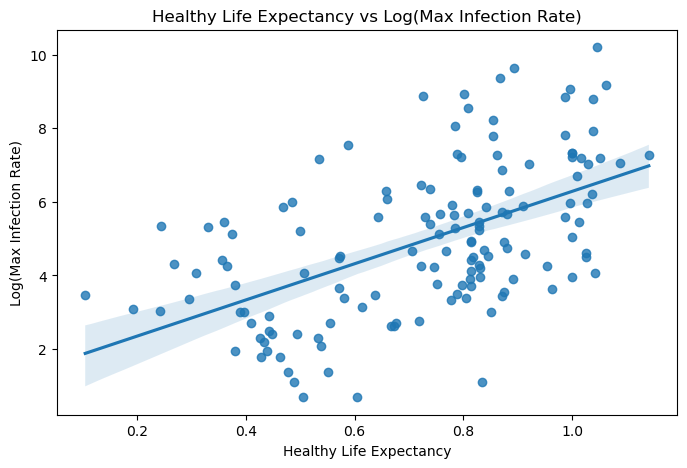

In [70]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = data["Healthy life expectancy"]
y = data["max_infection_rates"]

# Safe log transform (recommended)
y_log = np.log1p(y)

plt.figure(figsize=(8,5))
sns.regplot(x=x, y=y_log)

plt.xlabel("Healthy Life Expectancy")
plt.ylabel("Log(Max Infection Rate)")
plt.title("Healthy Life Expectancy vs Log(Max Infection Rate)")
plt.show()

### Plotting Freedom to make life choices vs maximum Infection rate

In [33]:
x = data["Freedom to make life choices"]
y = data["max_infection_rates"]

sns.scatterplot(x,np.log(y))

NameError: name 'data' is not defined

In [ ]:
x = data["Freedom to make life choices"]
y = data["max_infection_rates"]

sns.regplot(x,np.log(y))